# Unidade VI — Análise de Grupos

## Avaliação e interpretação de agrupamentos

**Carga estimada:** 3 horas  
**Pré-requisitos:** k-means, agrupamento hierárquico, DBSCAN, distâncias e padronização.

> **Pergunta norteadora:** se diferentes algoritmos sempre conseguem devolver algum agrupamento, como decidir se uma solução é estável, interpretável e útil?

Avaliar grupos não é procurar um único placar vencedor. É reunir evidências sobre estrutura, coesão, separação, concordância externa, estabilidade, cobertura e utilidade.

## Objetivos de aprendizagem

Ao concluir este notebook, você será capaz de:

- distinguir tendência de agrupamento, medidas internas e medidas externas;
- interpretar silhouette, Davies–Bouldin e Rand ajustado;
- explicar por que métricas diferentes podem preferir soluções diferentes;
- avaliar estabilidade diante de inicializações ou perturbações;
- construir perfis de grupos sem transformar associações em essências;
- selecionar e comunicar uma solução de maneira responsável.

In [1]:
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.datasets import load_wine, make_blobs
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

## 1. Avaliação começa antes da métrica

Han, Pei e Tong separam três questões: há estrutura não aleatória que justifique agrupar? quantos grupos oferecem uma granularidade útil? quão boa é uma solução produzida? Um algoritmo pode particionar até pontos uniformemente distribuídos; a existência de uma saída não prova a existência de grupos substantivos.

| Camada | Pergunta | Evidências possíveis |
|---|---|---|
| tendência | há estrutura agrupável? | visualização, conhecimento do domínio, estatística de Hopkins |
| interna | os grupos são coesos e separados segundo os próprios atributos? | silhouette, Davies–Bouldin, SSE |
| externa | a partição concorda com uma referência relevante? | Rand ajustado, homogeneidade, completude |
| estabilidade | a solução persiste sob pequenas mudanças? | repetição, reamostragem, perturbação |
| utilidade | os grupos apoiam o objetivo sem dano indevido? | perfis, validação com especialistas, monitoramento |

Essas camadas respondem a perguntas diferentes e não são intercambiáveis.

## 2. Medidas internas

### Silhouette

Para um objeto $i$, seja $a(i)$ sua distância média aos objetos do próprio grupo e $b(i)$ a menor distância média a outro grupo. Então:

$$s(i)=\frac{b(i)-a(i)}{\max\{a(i),b(i)\}}.$$

O valor fica entre −1 e 1. Próximo de 1 indica maior proximidade interna; perto de 0, fronteira; negativo, maior proximidade a outro grupo. O escore global é a média dos objetos.

### Índice Davies–Bouldin

Para cada grupo, compara sua dispersão interna com a separação do grupo mais semelhante. O índice é a média dessas piores comparações. **Menor é melhor**, com limite inferior 0. Ele favorece grupos compactos e separados e pode discordar de outras evidências quando as formas não são aproximadamente compactas.

,k,silhouette,Davies–Bouldin,SSE
0,2,0.725,0.408,6600.983
1,3,0.889,0.159,361.926
2,4,0.708,0.634,305.246
3,5,0.524,0.938,262.865
4,6,0.342,1.138,228.581


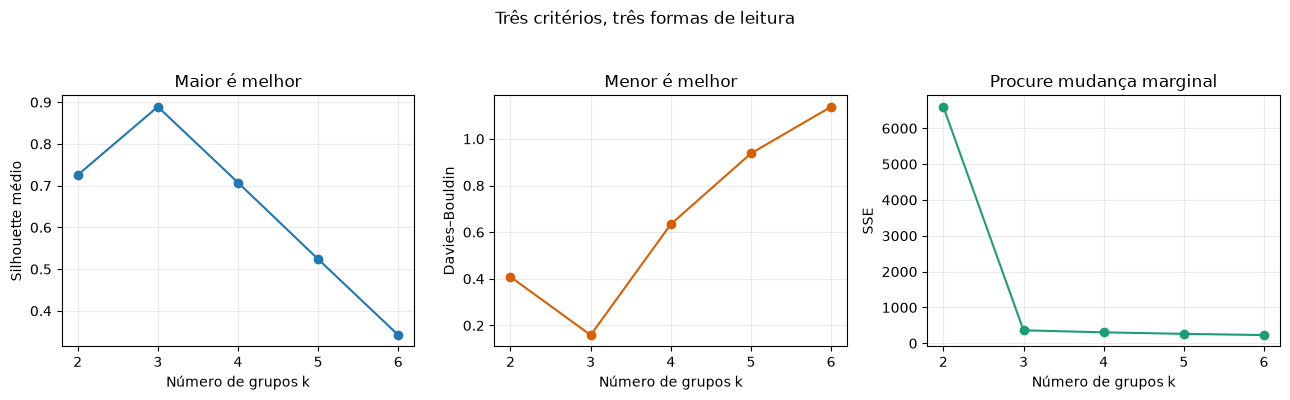

In [2]:
X_demo, y_demo = make_blobs(n_samples=360, centers=3, cluster_std=[0.65, 0.8, 0.7], random_state=RANDOM_STATE)
linhas_k = []
for k in range(2, 7):
    modelo = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = modelo.fit_predict(X_demo)
    linhas_k.append({"k": k, "silhouette": silhouette_score(X_demo, labels), "Davies–Bouldin": davies_bouldin_score(X_demo, labels), "SSE": modelo.inertia_})
metricas_k = pd.DataFrame(linhas_k)
display(metricas_k.round(3))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
axes[0].plot(metricas_k["k"], metricas_k["silhouette"], marker="o")
axes[0].set(title="Maior é melhor", xlabel="Número de grupos k", ylabel="Silhouette médio")
axes[1].plot(metricas_k["k"], metricas_k["Davies–Bouldin"], marker="o", color="#d95f02")
axes[1].set(title="Menor é melhor", xlabel="Número de grupos k", ylabel="Davies–Bouldin")
axes[2].plot(metricas_k["k"], metricas_k["SSE"], marker="o", color="#1b9e77")
axes[2].set(title="Procure mudança marginal", xlabel="Número de grupos k", ylabel="SSE")
for ax in axes: ax.grid(alpha=0.25)
fig.suptitle("Três critérios, três formas de leitura", y=1.04)
fig.tight_layout()
plt.show()

A SSE necessariamente diminui quando $k$ aumenta e, por isso, não deve ser minimizada sem penalizar complexidade. Silhouette e Davies–Bouldin possuem direções opostas, mas ambos dependem da distância e tendem a favorecer certas geometrias. Concordância entre eles reforça uma hipótese; não a transforma em verdade.

## 3. Medida externa: Rand ajustado

O índice de Rand examina pares de objetos: o par ficou junto nas duas partições ou separado nas duas? O **Rand ajustado (ARI)** corrige a concordância esperada ao acaso.

- $ARI=1$: partições idênticas, mesmo que os números dos rótulos sejam permutados;
- $ARI\approx0$: concordância próxima do acaso;
- $ARI<0$: concordância inferior ao esperado ao acaso.

O ARI exige rótulos externos ou outra partição de referência. Esses rótulos podem representar uma finalidade distinta daquela usada para agrupar; concordar com eles não é sempre o único objetivo.

In [3]:
referencia = np.array([0, 0, 0, 1, 1, 1, 2, 2, 2])
particoes = {
    "rótulos permutados": np.array([2, 2, 2, 0, 0, 0, 1, 1, 1]),
    "uma discordância": np.array([0, 0, 1, 1, 1, 1, 2, 2, 2]),
    "todos juntos": np.zeros(9, dtype=int),
}
tabela_ari = pd.DataFrame({"partição": particoes.keys(), "ARI": [adjusted_rand_score(referencia, p) for p in particoes.values()]})
display(tabela_ari.round(3))

,partição,ARI
0,rótulos permutados,1.000
1,uma discordância,0.643
2,todos juntos,0.000


## 4. Estabilidade: o resultado resiste a pequenas mudanças?

Uma solução instável pode mudar muito com outra inicialização, uma pequena perturbação ou uma amostra ligeiramente diferente. Podemos repetir o procedimento e comparar as partições por ARI — agora não contra uma verdade externa, mas entre execuções.

Estabilidade alta é desejável, porém não suficiente: um algoritmo pode reproduzir de forma estável uma estrutura irrelevante criada pela escala, por atributos redundantes ou por viés de amostragem.

,cenário,ARI médio,ARI mínimo,desvio do ARI
0,quatro grupos separados,1.000,1.00,0.000
1,uma nuvem sem quatro grupos claros,0.761,0.31,0.273


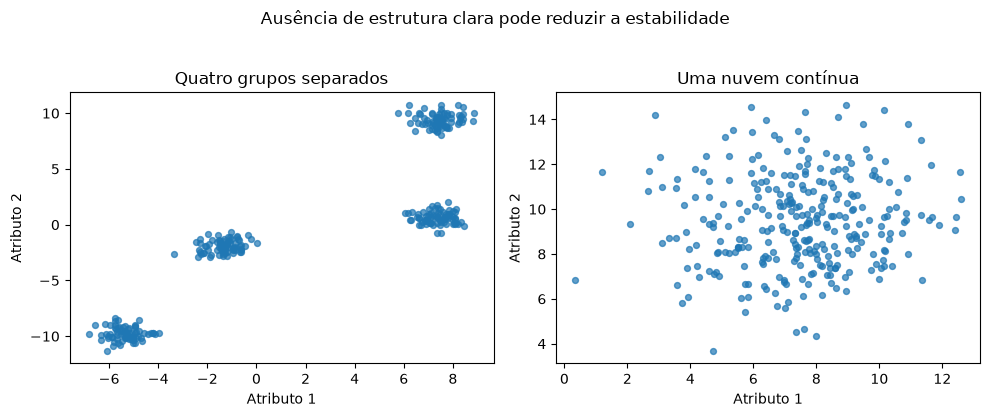

In [4]:
X_sep, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.55, random_state=8)
X_nuvem, _ = make_blobs(n_samples=300, centers=1, cluster_std=2.0, random_state=8)

def estabilidade_inicializacoes(X, repeticoes=12):
    rotulos = [KMeans(n_clusters=4, n_init=10, init="random", random_state=s).fit_predict(X) for s in range(repeticoes)]
    aris = [adjusted_rand_score(rotulos[i], rotulos[j]) for i, j in combinations(range(repeticoes), 2)]
    return np.mean(aris), np.min(aris), np.std(aris)

estabilidade = pd.DataFrame([
    ("quatro grupos separados", *estabilidade_inicializacoes(X_sep)),
    ("uma nuvem sem quatro grupos claros", *estabilidade_inicializacoes(X_nuvem)),
], columns=["cenário", "ARI médio", "ARI mínimo", "desvio do ARI"] )
display(estabilidade.round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, X, titulo in zip(axes, [X_sep, X_nuvem], ["Quatro grupos separados", "Uma nuvem contínua"]):
    ax.scatter(X[:, 0], X[:, 1], s=18, alpha=0.7)
    ax.set(title=titulo, xlabel="Atributo 1", ylabel="Atributo 2")
fig.suptitle("Ausência de estrutura clara pode reduzir a estabilidade", y=1.03)
fig.tight_layout()
plt.show()

## 5. Estudo integrador: três famílias no conjunto Wine

O conjunto Wine contém 178 vinhos descritos por 13 medições químicas e um rótulo de cultivar. Usaremos os atributos padronizados para agrupar. O rótulo será reservado para uma avaliação externa: ele não participa da formação dos grupos.

Compararemos k-means, Ward e DBSCAN. Para o DBSCAN, silhouette e Davies–Bouldin serão calculados apenas nos objetos não marcados como ruído; por isso, registraremos também a **cobertura**, isto é, a proporção efetivamente atribuída a grupos. Sem essa coluna, a comparação interna seria enganosa.

,método,grupos,ruídos,cobertura,silhouette_não_ruído,DB_não_ruído,ARI_externo
0,k-means (k=3),3,0,1.000,0.285,1.389,0.897
1,Ward (k=3),3,0,1.000,0.277,1.419,0.790
2,DBSCAN,2,55,0.691,0.348,1.124,0.329


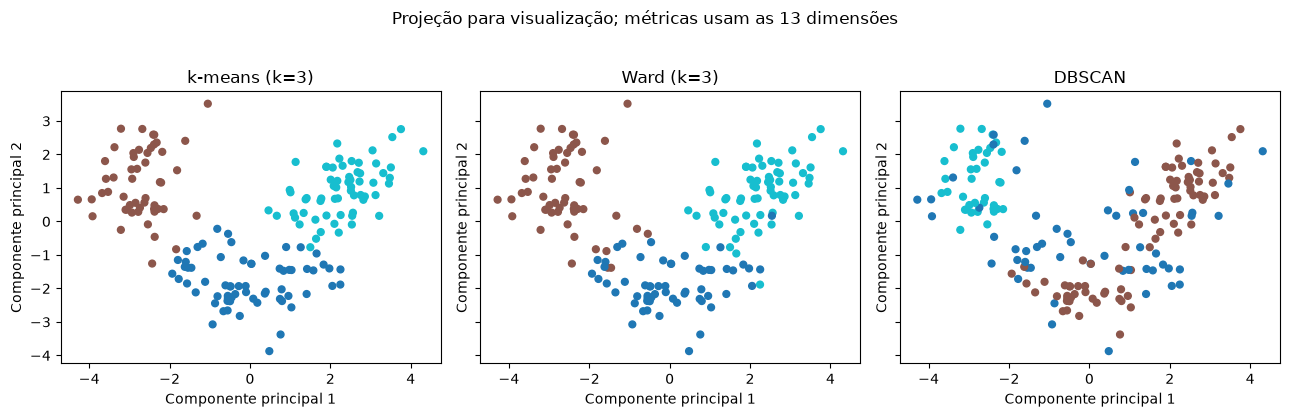

In [5]:
wine = load_wine(as_frame=True)
X_wine_original = wine.data
X_wine = StandardScaler().fit_transform(X_wine_original)
y_wine = wine.target.to_numpy()
modelos = {
    "k-means (k=3)": KMeans(n_clusters=3, n_init=20, random_state=RANDOM_STATE),
    "Ward (k=3)": AgglomerativeClustering(n_clusters=3, linkage="ward"),
    "DBSCAN": DBSCAN(eps=2.2, min_samples=5),
}
resultados, rotulos_wine = [], {}
for nome, modelo in modelos.items():
    labels = modelo.fit_predict(X_wine)
    rotulos_wine[nome] = labels
    mask = labels != -1
    n_grupos = len(set(labels[mask]))
    resultados.append({
        "método": nome, "grupos": n_grupos, "ruídos": int((~mask).sum()),
        "cobertura": mask.mean(),
        "silhouette_não_ruído": silhouette_score(X_wine[mask], labels[mask]) if n_grupos > 1 else np.nan,
        "DB_não_ruído": davies_bouldin_score(X_wine[mask], labels[mask]) if n_grupos > 1 else np.nan,
        "ARI_externo": adjusted_rand_score(y_wine, labels),
    })
comparacao_wine = pd.DataFrame(resultados)
display(comparacao_wine.round(3))

X_pca = PCA(n_components=2).fit_transform(X_wine)
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)
for ax, (nome, labels) in zip(axes, rotulos_wine.items()):
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="tab10", s=24)
    ax.set(title=nome, xlabel="Componente principal 1", ylabel="Componente principal 2")
fig.suptitle("Projeção para visualização; métricas usam as 13 dimensões", y=1.03)
fig.tight_layout()
plt.show()

### Por que o “melhor” valor isolado pode enganar?

O DBSCAN obtém silhouette mais alto e Davies–Bouldin mais baixo **entre os objetos mantidos**, mas deixa uma parcela relevante como ruído, produz dois grupos e apresenta menor concordância com os três cultivares. Já o k-means cobre todos os objetos e possui maior ARI externo, embora suas métricas internas sejam menos favoráveis.

A escolha depende do objetivo. Se os cultivares constituem a referência relevante, o k-means é mais defensável neste experimento. Se a pergunta procura apenas regiões químicas muito densas e admite baixa cobertura, o DBSCAN pode revelar outra estrutura. Não se deve escolher o método depois de ocultar a métrica inconveniente.

## 6. Perfilar grupos sem criar estereótipos

Depois de selecionar uma solução provisória, descrevemos os grupos nos atributos originais e padronizados. Médias padronizadas positivas indicam valores acima da média global; negativas, abaixo. Isso facilita comparar escalas, mas não substitui distribuições, tamanhos e exemplos individuais.

,n
0,65
1,51
2,62


,alcohol,malic_acid,color_intensity,hue,proline
grupo,,,,,
0,-0.93,-0.39,-0.90,0.46,-0.75
1,0.16,0.87,0.94,-1.16,-0.41
2,0.84,-0.30,0.17,0.47,1.13


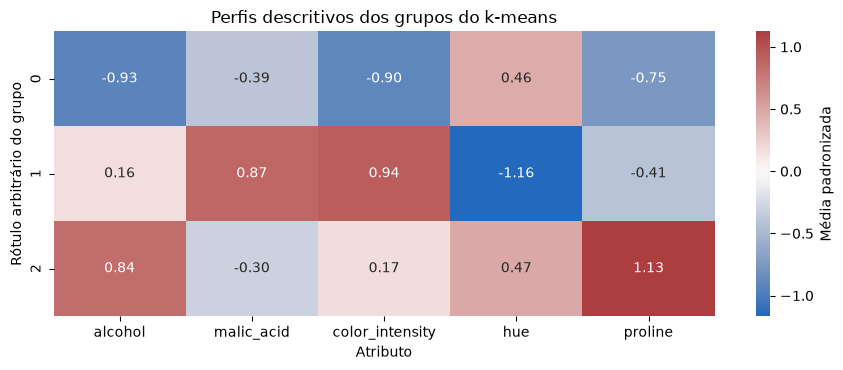

In [6]:
labels_kmeans = rotulos_wine["k-means (k=3)"]
nomes_perfil = ["alcohol", "malic_acid", "color_intensity", "hue", "proline"]
indices_perfil = [X_wine_original.columns.get_loc(c) for c in nomes_perfil]
perfis_z = pd.DataFrame(X_wine[:, indices_perfil], columns=nomes_perfil).assign(grupo=labels_kmeans).groupby("grupo").mean()
tamanhos = pd.Series(labels_kmeans).value_counts().sort_index().rename("n")
display(tamanhos.to_frame())
display(perfis_z.round(2))

fig, ax = plt.subplots(figsize=(9, 3.8))
sns.heatmap(perfis_z, annot=True, fmt=".2f", center=0, cmap="vlag", ax=ax, cbar_kws={"label": "Média padronizada"})
ax.set(title="Perfis descritivos dos grupos do k-means", xlabel="Atributo", ylabel="Rótulo arbitrário do grupo")
plt.tight_layout()
plt.show()

## 7. Seleção responsável de uma solução

Antes de recomendar grupos:

1. registre unidade de análise, atributos, transformações, escala e distância;
2. verifique se há estrutura e compare métodos coerentes com a geometria esperada;
3. relate mais de uma métrica, número e tamanho dos grupos, ruído e cobertura;
4. teste estabilidade a sementes, amostras e parâmetros próximos;
5. construa perfis com distribuições e incerteza, não apenas médias;
6. valide interpretações com conhecimento do domínio;
7. evite nomes essencialistas como “clientes ruins”; prefira descrições observáveis e temporais;
8. avalie consequências antes de usar grupos para decisões sobre pessoas;
9. monitore mudança dos dados e permita revisar ou abandonar a segmentação.

Rótulos de grupo são arbitrários: o grupo 0 não é inferior ao grupo 1. Além disso, pertencimento resume semelhanças nos atributos escolhidos; não define a identidade de um objeto ou de uma pessoa.

## 8. Atividades

**U06-NB03-V01.** Uma solução possui silhouette 0,71, mas cria um grupo com apenas dois objetos extremos. Explique por que o valor não basta para aceitar a solução e indique três verificações adicionais.

**U06-NB03-E01.** Para o objeto A, $a(A)=2$ e $b(A)=5$; para B, $a(B)=4$ e $b(B)=3$. Calcule os dois silhouettes, interprete-os e obtenha a média desses objetos.

**U06-NB03-E02.** Três soluções apresentam: A — silhouette 0,42, Davies–Bouldin 0,85, ARI externo 0,31, estabilidade 0,92 e cobertura 100%; B — 0,35, 0,98, 0,78, 0,88 e 100%; C — 0,47, 0,70, 0,25, 0,40 e 68%. Se os rótulos externos representam a finalidade da aplicação, compare as soluções e faça uma recomendação justificada.

**U06-NB03-E03.** Explique por que `[0,0,1,1,2,2]` e `[2,2,0,0,1,1]` têm ARI 1. O que isso ensina sobre os números atribuídos aos grupos?

**U06-NB03-E04.** Usando a tabela do estudo Wine, compare k-means, Ward e DBSCAN. Recomende uma solução para aproximar os cultivares e outra para investigar regiões densas, deixando explícitas as limitações.

**U06-NB03-E05.** Proponha um pequeno protocolo para criar, nomear, validar e monitorar perfis de clientes sem transformar os grupos em estereótipos fixos.

## 9. Síntese

- Avaliar agrupamentos inclui tendência, qualidade interna, concordância externa, estabilidade e utilidade.
- Silhouette maior e Davies–Bouldin menor indicam coesão e separação sob hipóteses específicas.
- ARI compara pares, corrige o acaso e ignora permutações dos números dos grupos.
- Cobertura e ruído devem acompanhar métricas calculadas após excluir objetos.
- Estabilidade é evidência necessária, mas não valida atributos ou interpretações inadequadas.
- Perfis descrevem a solução nos dados observados; não revelam essências nem efeitos causais.
- A melhor solução é defensável para uma finalidade explícita, e não apenas vencedora em um placar.

## Referências

- HAN, J.; PEI, J.; TONG, H. *Data Mining: Concepts and Techniques*. 4. ed. Morgan Kaufmann, 2023. Seção 8.5.
- ROUSSEEUW, P. J. Silhouettes: a graphical aid to the interpretation and validation of cluster analysis. *Journal of Computational and Applied Mathematics*, v. 20, p. 53–65, 1987.
- SCIKIT-LEARN DEVELOPERS. Clustering performance evaluation. Documentação oficial.
- UCI MACHINE LEARNING REPOSITORY. Wine Recognition Dataset, disponibilizado no scikit-learn.

As figuras são autorais e geradas localmente.